In [1]:
from utils import * 
import subprocess
import json 
import glob
from msa import msa_main
from files.rnafold import RNAFoldOutput
import shutil
from ppi import * 

%load_ext autoreload 
%autoreload 2

# Because of the signal peptide, I don't think this would be a protein that exists in the membrane of a viral-like envelope. 
# It must be using host peptidase/secretion machinery, which implies it ends up in the host cell membrane.

In [3]:
CLUSTER_ID_TO_GENE_ID_MAP = pd.DataFrame.from_dict(json.load(open('../data/genes/clusters.json', 'r')), orient='index', columns=['cluster_id']).reset_index(names='gene_id')
CLUSTER_ID_TO_GENE_ID_MAP = {cluster_id:df.gene_id.tolist() for cluster_id, df in CLUSTER_ID_TO_GENE_ID_MAP.groupby('cluster_id')}

In [4]:
tmhmm_file = TMHMMFile.from_file('../data/genes/tmhmm/genes.txt')
tmhmm_df = tmhmm_file.to_df()

INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)

In [6]:
# Load in contigs downloaded from ggKbase for use in ORF extension. 
GGKBASE_DIR = '../data/genes/ggkbase/'
contigs = dict()
for path in glob.glob(os.path.join(GGKBASE_DIR, 'contigs', '*')):
    contigs[os.path.basename(path).replace('.fasta', '')] = FASTAFile.from_file(path).seqs[0]
print('Loaded', len(contigs), 'contigs from', GGKBASE_DIR)

Loaded 8 contigs from ../data/genes/ggkbase/


In [7]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))

SEQ_TO_GENE_ID_MAP = genes_df.reset_index(names='gene_id').set_index('seq').gene_id.to_dict()
SEQ_TO_CLUSTER_ID_MAP = genes_df.set_index('seq').cluster_id.to_dict() # Do this before filtering out all non-cluster_20. 

genes_df = genes_df[(genes_df.cluster_id == 20)].copy()
genes_df['gc_content'] = genes_df.nt_seq.apply(get_gc_content)

FASTAFile.from_df(genes_df).write('../data/genes/cluster_20.faa')
if not os.path.exists('../data/genes/cluster_20.afa'):
    subprocess.run('muscle -align ../data/genes/cluster_20.faa -output ../data/genes/cluster_20.afa', shell=True, check=True)

for row in genes_df.itertuples():
    print(f'{row.Index} ({row.start}-{row.stop}) {row.gc_content * 100:.1f}% GC')

print('\nMinimum cluster_20 gene length:', genes_df.seq.apply(len).min())
print('Maximum cluster_20 gene length:', genes_df.seq.apply(len).max())

GENOME_ID_TO_GENE_ID_MAP = genes_df.reset_index(names='gene_id').set_index('genome_id').gene_id.to_dict()
GENOME_ID_TO_GENOME_MAP = {genome_id:FASTAFile.from_file(f'../data/genomes/{genome_id}.fasta').seqs[0] for genome_id in genes_df.genome_id.unique()}

orfm.bz_0.1_114 (10257-10553) 37.8% GC
orfm.bz_4.1_121 (10937-11230) 37.5% GC
orfm.bz_11.1_116 (11033-11324) 37.8% GC

Minimum cluster_20 gene length: 96
Maximum cluster_20 gene length: 97


In [164]:
# After reading about filamentous bacteriophages, I am going to look more thoroughly for other potential structural homologs. Criteria
# to consider an ORF a potential candidate are:
#   (1) Probably less than 110 residues in length; I am not going to put a strict lower-bound on the size, as it is unclear if a signal peptide is required. 
#       Also, the filamentous bacteriophage MCPs seem to be more like ~50 aa, not 70 aa. 
#   (2) At least one transmembrane helix. 
#   (3) At least 2 positive residues (K or R) in the last 10 amino acids. 
#   (4) Predicted by Prodigal (will remove this requirement if I don't get hits).
# I then removed certain proteins which did not make sense, either because they belong to larger conserved clusters (e.g. cluster_10), or have a structure 
# that bears no resemblance to cluster_20. 

df = pd.read_csv('../data/genes/genes.csv', index_col=0)
df['cluster_id'] = df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
df['num_tmhs'] = df.index.map(TMHMMFile.from_file('../data/genes/tmhmm/genes.txt').to_df().drop_duplicates('gene_id').set_index('gene_id').num_tmhs)

# I only ran DeepTMHMM and SignalP on sequences that passed the preliminary filters (criteria 1-4 above).
deep_tmhmm_df = DeepTMHMMFile.from_file('../data/genes/deep_tmhmm/cluster_20_candidates.gff3').to_df()

SIGNALP_FIELDS = ['gene_id', 'prediction', 'other', 'sp_sec_spi', 'lipo_sec_spii', 'tat_tat_spi', 'tatlipo_tat_spii', 'pilin_sec_spiii', 'cleavage_site_position']
signalp_df = pd.read_csv('../data/genes/signalp/cluster_20_candidates/prediction_results.txt', sep='\t', comment='#', names=SIGNALP_FIELDS)
signalp_df = signalp_df[signalp_df.prediction == 'SP'].copy()

df['topology_string'] = df.index.map(deep_tmhmm_df[~deep_tmhmm_df.index.duplicated()].topology_string)
df['num_tmhs'] = df.topology_string.str.count('M')
df['num_sp_predictions'] = df.index.isin(signalp_df.gene_id.values).astype(int) + df.topology_string.str.contains('S').astype(int)

filters = dict()
filters['longer_than_110_aa'] = df.length_from_start_codon > 110 
filters['shorter_than_40_aa'] = df.length_from_start_codon < 40
filters['no_transmembrane_helix'] = df.num_tmhs == 0
filters['basic_c_terminus'] = (df.seq.str[-10:].str.count('K') + df.seq.str[-10:].str.count('R')) < 2
filters['not_prodigal_supported'] = df.prodigal_gene_id.isnull()
filters['cluster_4'] = df.cluster_id == 4 # Cluster 4 definitely does not seem to be a valid candidate, despite having similar numbers of TMHs. 
filters['cluster_10'] = df.cluster_id == 10 # Cluster 10 is not consistently annotated with TMHs, structure is wrong.
filters['cluster_45'] = df.cluster_id == 45 # Cluster 45 has a clump of helices at one end with reasonable confidence, seems wrong. 
filters['orfm.bz_4.1_71'] = df.index == 'orfm.bz_4.1_71' # Meets all criteria, and has a plausible topology, but orfm.bz_4.1_121 is a better candidate. 
filters['incorrect_topology'] = ~df.topology_string.isin(['SOMI', 'OMI'])
df = apply_filters(filters, df)

assert np.all(genes_df.index.isin(df.index)), 'Some confirmed cluster_20 proteins are missing.'
assert df.genome_id.nunique() == 11, 'Some genomes are missing a candidate.'
assert np.all(df.num_tmhs == 1), 'DeepTMHMM does not predict exactly one TMH for all genes.'

# # Then, ran SignalP and DeepTMHMM on the candidates to determine if any have signal peptides, and if the predicted topology matches what I expect.
# print()
# for row in df.itertuples():
#     print(f'>{row.Index}')
#     print(f'{row.seq}')

deep_tmhmm_df = deep_tmhmm_df[deep_tmhmm_df.index.isin(df.index.values)].copy()
df['tmh_start'] = deep_tmhmm_df[deep_tmhmm_df.annotation == 'TMhelix'].start
df['tmh_stop'] = deep_tmhmm_df[deep_tmhmm_df.annotation == 'TMhelix'].end

print()
for row in df.itertuples():
    c_terminus = row.seq[row.tmh_stop:]
    n_basic_residues = c_terminus.count('K') + c_terminus.count('R')
    print(f'{row.Index} percentage of basic residues in C-terminus ({len(c_terminus)} aa): {100 * n_basic_residues / len(c_terminus):.2f}%')

DeepTMHMMFile: Found 3line file at ../data/genes/deep_tmhmm/cluster_20_candidates.3line
apply_filters: 176 entries removed by longer_than_110_aa.
apply_filters: 792 entries removed by shorter_than_40_aa.
apply_filters: 8 entries removed by no_transmembrane_helix.
apply_filters: 1041 entries removed by basic_c_terminus.
apply_filters: 1204 entries removed by not_prodigal_supported.
apply_filters: 10 entries removed by cluster_4.
apply_filters: 6 entries removed by cluster_10.
apply_filters: 2 entries removed by cluster_45.
apply_filters: 1 entries removed by orfm.bz_4.1_71.
apply_filters: 1621 entries removed by incorrect_topology.

orfm.bz_0.1_114 percentage of basic residues in C-terminus (15 aa): 33.33%
orfm.bz_1.1_76 percentage of basic residues in C-terminus (25 aa): 20.00%
orfm.bz_2.1_95 percentage of basic residues in C-terminus (25 aa): 20.00%
orfm.bz_3.1_97 percentage of basic residues in C-terminus (19 aa): 26.32%
orfm.bz_4.1_121 percentage of basic residues in C-terminus (14 

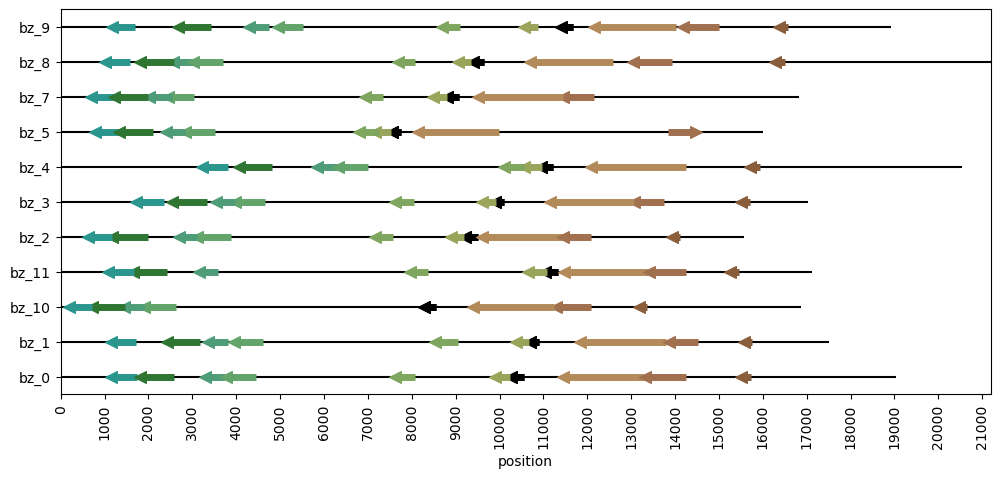

In [ ]:
cluster_ids = df.cluster_id.values.tolist() + [8, 7, 0, 4, 5, 6, 1, 3, 2]

colors = ['#8A5E3B', '#A0704F', '#B38A5A', '#9AA45A', '#7FA65E', '#62A46A', '#4F9D78', "#2F7632", "#2B968E", "#5691D8", "#323986"]

palette = dict(zip([8, 7, 0, 4, 5, 6, 1, 3, 2], colors))

fig, ax = plt.subplots(figsize=(12, 5))

figure_df = df.copy()
figure_df = pd.concat([figure_df, pd.read_csv('../data/genes/genes.csv', index_col=0)])
figure_df['cluster_id'] = figure_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
figure_df['gene_id'] = figure_df.index
figure_df = figure_df[figure_df.cluster_id.isin(cluster_ids)].copy()

plot_orfs(figure_df, ax=ax, palette=palette)



In [180]:
# Use the DeepTMHMM signal peptide predictions, to process the genes, i.e. remove the signal peptide. 
# This is just removing the amino acids classified as part of a signal protein from the alignment. 

topology_strings = deep_tmhmm_df.topology_string_full.to_dict()

for row in df.itertuples():
    topology = np.array(list(topology_strings[row.Index].strip())) 
    seq = np.array(list(row.seq))
    seq_processed = ''.join(seq[topology != 'S'])

    if row.Index == 'orfm.bz_5.1_98': # Length doesn't make as much sense with this one. 
        seq_processed = row.seq

    df.loc[row.Index, 'seq_processed'] = seq_processed # Add the sequence with the signal peptide removed to the DataFrame. 
    print(f'Signal peptide length in {row.Index}:', (topology == 'S').sum(), f'({len(seq_processed)} aa)', '(supported by SignalP)' if (row.num_sp_predictions > 1) else '')

Signal peptide length in orfm.bz_0.1_114: 27 (70 aa) (supported by SignalP)
Signal peptide length in orfm.bz_1.1_76: 0 (67 aa) 
Signal peptide length in orfm.bz_2.1_95: 24 (72 aa) 
Signal peptide length in orfm.bz_3.1_97: 0 (63 aa) 
Signal peptide length in orfm.bz_4.1_121: 26 (70 aa) (supported by SignalP)
Signal peptide length in orfm.bz_5.1_98: 20 (67 aa) 
Signal peptide length in orfm.bz_7.1_99: 0 (68 aa) 
Signal peptide length in orfm.bz_8.1_147: 21 (64 aa) (supported by SignalP)
Signal peptide length in orfm.bz_9.1_116: 0 (57 aa) 
Signal peptide length in orfm.bz_10.1_77: 28 (61 aa) 
Signal peptide length in orfm.bz_11.1_116: 26 (70 aa) (supported by SignalP)


In [182]:
genes_df = df.copy()
genes_df['gc_content'] = genes_df.nt_seq.apply(get_gc_content)

for row in genes_df.itertuples():
    print(f'{row.Index} ({row.start}-{row.stop}) {row.gc_content * 100:.1f}% GC')


orfm.bz_0.1_114 (10257-10553) 37.8% GC
orfm.bz_1.1_76 (10692-10898) 33.8% GC
orfm.bz_2.1_95 (9218-9521) 34.4% GC
orfm.bz_3.1_97 (9897-10095) 34.4% GC
orfm.bz_4.1_121 (10937-11230) 37.5% GC
orfm.bz_5.1_98 (7554-7766) 33.3% GC
orfm.bz_7.1_99 (8801-9076) 35.8% GC
orfm.bz_8.1_147 (9386-9652) 33.7% GC
orfm.bz_9.1_116 (11395-11677) 37.4% GC
orfm.bz_10.1_77 (8287-8563) 34.1% GC
orfm.bz_11.1_116 (11033-11324) 37.8% GC


In [186]:
# Write the processed sequences to a FASTA file for alignment. 

database_df = genes_df.copy()
database_path = '../data/genes/cluster_20.faa'
name = 'cluster_20_processed'

FASTAFile.from_df(database_df.assign(seq=database_df.seq_processed, description='')).write(database_path)
msa_main(database_path, query_gene_ids=df.index.tolist(), fmt='afa', name=name, output_dir='../data/genes/muscle', min_coverage=0.9)

# Also generate MSAs in the correct format for AlphaFold.
msa_paths = msa_main(database_path, query_gene_ids=df.index.tolist(), fmt='a3m', name=name, database_dir='../data/genes/mmseqs/db/', output_dir='../data/genes/mmseqs', min_coverage=0.75, sensitivity=50)

msa_dereplicate: min_coverage = 0.9
msa_dereplicate: min_seq_identity = 0.95
msa_dereplicate: coverage_mode = 5
msa_dereplicate: 11 representative sequences when clustered at 0.95 minimum identity.
msa_build_afa: muscle -align /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_20_reps.faa -output /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_20_processed.afa
msa_build_afa: clipkit /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_20_processed.afa -o /home/prichter/Documents/banfield/betazoid/data/genes/muscle/cluster_20_processed.trimmed.afa -g 0.8 --log
msa_dereplicate: min_coverage = 0.75
msa_dereplicate: min_seq_identity = 0.95
msa_dereplicate: coverage_mode = 5
msa_dereplicate: 11 representative sequences when clustered at 0.95 minimum identity.
msa_build_a3m: num_iterations = 1
msa_build_a3m: sensitivity = 50
msa_build_a3m: mmseqs createdb ../data/genes/mmseqs/cluster_20_reps.faa ../data/genes/mmseqs/db/database
msa_build

In [ ]:
seq_col = 'seq_processed'
num_subunits = 1

inputs = list()
for path in msa_paths:
    with open(path, 'r') as f:
        msa = f.read()
        print(f'Number of sequences in {path}:', msa.count('>'))

        gene_id = os.path.basename(path).replace('.a3m', '')
        input = AlphaFoldInputFile(name=f'{get_genome_id(gene_id)}_cluster_20_{num_subunits}mer_processed', num_seeds=1, dialect='alphafoldserver')
        input.add_seq(database_df.loc[gene_id, seq_col], unpaired_msa=msa, paired_msa="", n=num_subunits)
        inputs.append(input)

inputs = [input.get_info() for input in inputs]
with open('/home/prichter/Downloads/cluster_20.json', 'w') as f:
    json.dump(inputs, f)

Number of sequences in ../data/genes/mmseqs/orfm.bz_0.1_114.a3m: 2
Number of sequences in ../data/genes/mmseqs/orfm.bz_10.1_77.a3m: 2
Number of sequences in ../data/genes/mmseqs/orfm.bz_5.1_98.a3m: 2
Number of sequences in ../data/genes/mmseqs/orfm.bz_2.1_95.a3m: 5
Number of sequences in ../data/genes/mmseqs/orfm.bz_11.1_116.a3m: 3
Number of sequences in ../data/genes/mmseqs/orfm.bz_4.1_121.a3m: 3
Number of sequences in ../data/genes/mmseqs/orfm.bz_9.1_116.a3m: 4
Number of sequences in ../data/genes/mmseqs/orfm.bz_3.1_97.a3m: 2
Number of sequences in ../data/genes/mmseqs/orfm.bz_8.1_147.a3m: 3
Number of sequences in ../data/genes/mmseqs/orfm.bz_7.1_99.a3m: 4
Number of sequences in ../data/genes/mmseqs/orfm.bz_1.1_76.a3m: 6


0	T...VCSDAGSFNSTCVTITDLGKGIIAVFSVLVTGDNAGVLITTAITIAIVVAVFDLS.RGKESYIGRHF..............RRM	88	orfm.bz_11.1_116
0	T...SCTDAGDFVGICNTVIGIANGTLAVISILFTGNNASIIIEAALIVTIVGAILDLS.RGKSSWLRSKF..............ERV	88	orfm.bz_0.1_114
0	T...ACSDAGDFEGVCTSLSGLFNATMALISIVATGSNASIIITAAVILAIVTFFVDMA.RGEKSWLRAKM..............RNL	88	orfm.bz_4.1_121
0	...SAAFN.......VTTITDAMNMIWAILGNI..NDNISVIISIIVSFAILALISWIAKDWLRGLLQTAM...............KR	88	orfm.bz_10.1_77
0	......MV.......AVNITATMQIIWDLVWNL..VDNTGAIVGLILIGIIIGVMIVIK.KFISNTLNKSL...............EK	88	orfm.bz_9.1_116
0	......IN.......MTQITDAINITWAILQNI..IDNTGVIIGFIVLIFVIGLIGFLL.LFVKKLLTNLIDHVGKGGNVGKGGKGGY	88	orfm.bz_2.1_95
0	L...TTVD.......LSILNTTIDAFINIAAYI..VTRIDVLVGLALLGIIIGAATKMG.KALGGLFDKIFK............PGTK	88	orfm.bz_3.1_97
0	VKKRMAID.......LSILNDSVTAFMDVGATI..VSRTDVLIGLAMIGIVIFIAKKMG.NGFGEMFAKFTS...........GKTGK	88	orfm.bz_5.1_98
0	VK.NLAIN.......TTEITDALNAIWAIVQNI..VDHTGTIISLILIGVVIAILYVIV.RFLKKTLMKATET..........GDGRN	88	orfm.bz_1.1_76
0	VI.NMVVD...

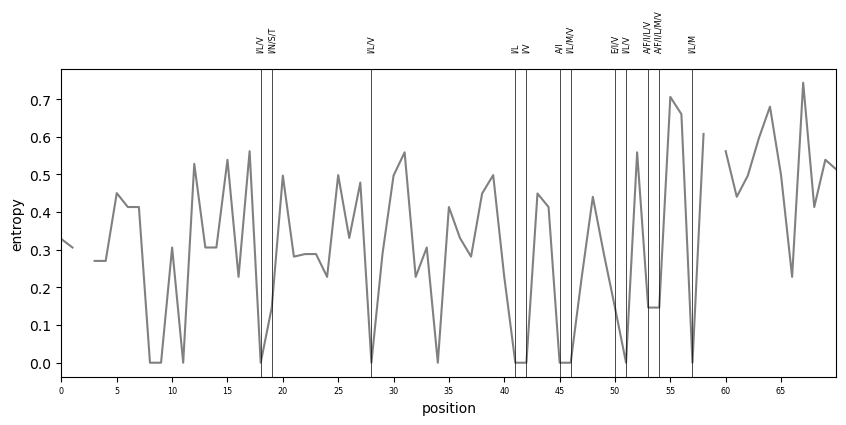

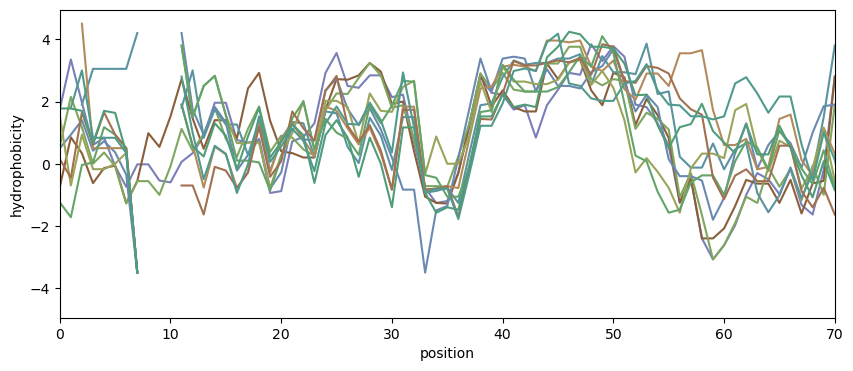

In [ ]:
msa = MSAFile.from_file('../data/genes/muscle/cluster_20_processed.afa') # Load the untrimmed alignment.
# msa = MSAFile.from_file('../data/genes/cluster_20.afn') # Load the untrimmed alignment.
# plot_hydrophobicity(msa, x_max=70)
# msa.show()


x_min, x_max = 0,70 
fig, ax = plt.subplots(figsize=(10, 4))
plot_entropy(msa, ax=ax, x_min=x_min, x_max=x_max, alphabet=REDUCED_ALPHABET, annotate=True)

x_min, x_max = 0,70 
fig, ax = plt.subplots(figsize=(10, 4))
plot_hydrophobicity(msa, x_max=70, ax=ax, palette={gene_id:GENOME_ID_COLORS.get(get_genome_id(gene_id)) for gene_id in genes_df.index})
msa.show()

In [ ]:
# # The structure for cluster_20 proteins is extremely weak, so I ran another BLAST search against ggKbase 
# # in an attempt to find homologs. I then filtered the hits by manual inspection and refinement of the MSA. 
# GGKBASE_DIR = '../data/genes/ggkbase/'

# nt_seqs = dict(zip(FASTAFile.from_file(os.path.join(GGKBASE_DIR, 'cluster_20.fna')).ids, FASTAFile.from_file(os.path.join(GGKBASE_DIR, 'cluster_20.fna')).seqs))

# ggkbase_df = FASTAFile.from_file(os.path.join(GGKBASE_DIR, 'cluster_20.faa')).to_df()
# ggkbase_df['nt_seq'] = ggkbase_df.index.map(nt_seqs)
# ggkbase_df.index = [gene_id.split('|')[0] for gene_id in ggkbase_df.index] # Clean up the ggKbase gene IDs.
# ggkbase_df['seq'] = ggkbase_df.seq.str.replace('*', '', regex=False)
# ggkbase_df['contig_id'] = ['_'.join(gene_id.split('_')[:-1]) for gene_id in ggkbase_df.index]
# ggkbase_df['start'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[1].strip())) # Convert to zero-indexed for my sanity. 
# ggkbase_df['stop'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[2].strip()))
# ggkbase_df['strand'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[3].strip())).replace({-1:'-', 1:'+'})
# ggkbase_df['length'] = ggkbase_df.seq.apply(len)

# print('Number of unique contigs:', ggkbase_df.contig_id.nunique())

# # Replace the shorter sequence corresponding to orfm.bz_11.1_116 with the one in genes_df. 
# ggkbase_df.loc['SR-VP_9_9_2021_56_4A_0_95m_scaffold_3886_3', 'seq'] = genes_df.loc['orfm.bz_11.1_116', 'seq']
# ggkbase_df.loc['SR-VP_9_9_2021_56_4A_0_95m_scaffold_3886_3', 'nt_seq'] = genes_df.loc['orfm.bz_11.1_116', 'nt_seq']
# ggkbase_df.loc['SR-VP_9_9_2021_56_4A_0_95m_scaffold_3886_3', 'stop'] += (12 * 3)

# filters = dict()
# filters['subject_too_long'] = ggkbase_df.seq.apply(len) > 110
# filters['duplicate_gene_id'] = ggkbase_df.index.duplicated(keep='first')
# filters['duplicate_nt_sequence'] = ggkbase_df.nt_seq.duplicated(keep='first') & ~ggkbase_df.nt_seq.isnull()
# filters['weak_alignment'] = ggkbase_df.index == 'SR2-18-Sp2_coassembly_scaffold_597830_2'
# filters['no_nt_seq'] = ggkbase_df.nt_seq.isnull()

# ggkbase_df = apply_filters(filters, ggkbase_df)
# print('Number of ggKbase hits remaining after filtering:', len(ggkbase_df), end='\n\n')
# assert np.all(genes_df.seq.isin(ggkbase_df.seq.values)), 'Some of the sequences in genes_df are not present in the BLAST results.'


# for row in ggkbase_df.itertuples():
#     gene_id =  genes_df[genes_df.seq == row.seq].index[0] if (row.seq in genes_df.seq.values) else None
#     print(row.Index, f'({gene_id})' if (gene_id is not None) else '')
    


In [ ]:
# Based on the data, the possibilities seem to be:
#   (1) The proteins which are longer at the N-terminus are erroneously extendeded. 
#   (2) The proteins which are shorter at the N-terminus are erroneously truncated. 
#   (3) The ORF boundaries are all correct, and only some of the proteins have the N-terminal domain. 

# It should be noted that many of the aligned proteins are from SR-VP, and may be closely related. Conservation 
# Should perhaps be taken with a grain of salt. For example, orfm.bz_0.1_114 and SR-VP_11_27_2022_S1_60cm_scaffold_16350_2 seem to be
# identical, but Prodigal selected a different start site. This is also true for orfm.bz_11.1_116 and SR-VP_9_9_2021_31_2B_1_5m_scaffold_23596_3.

# I don't think there is enough information to use conservation as a good signal for if the N-terminal helix is real, particularly because 
# signal peptides are not conserved at the sequence level [Auclair et. al. 2011]. Instead, I am going to look at potential extensions 
# and truncations of each sequence. 


In [184]:
# # Based on the analysis above, the most likely scenario seems to be that some of the proteins are N-terminally truncated, 
# # and that the ones with an N-terminal region have a signal peptide which is not present in other Betazoids. This would mean that the
# # signal peptide is not part of the final structure, which might affect hypotheses about its function. 

# # Write the de-duplicated and N-terminally extended sequences (with the ggKbase ID) to FASTA files.
# FASTAFile.from_df(ggkbase_df.assign(seq=ggkbase_df.seq_extended).drop_duplicates('seq')).write('../data/genes/cluster_20_extended.faa')

# tmhmm_df = TMHMMFile.from_file('../data/genes/tmhmm/cluster_20_extended.txt').to_df()
# deep_tmhmm_df = DeepTMHMMFile.from_file('../data/genes/deep_tmhmm/cluster_20_extended.gff3').to_df()

# SIGNALP_FIELDS = ['gene_id', 'prediction', 'other', 'sp_sec_spi', 'lipo_sec_spii', 'tat_tat_spi', 'tatlipo_tat_spii', 'pilin_sec_spiii', 'cleavage_site_position']
# signalp_df = pd.read_csv('../data/genes/signalp/cluster_20_extended/prediction_results.txt', sep='\t', comment='#', names=SIGNALP_FIELDS)

# print('DeepTMHMM predictions:')
# for gene_id, df in deep_tmhmm_df.groupby('gene_id'):
#     num_tmhs = (df.location == 'TMhelix').sum()
#     has_sp = 'signal' in df.location.values
#     print(f'{gene_id}: {num_tmhs} TMHs,', 'signal peptide' if has_sp else 'no signal peptide')

# print('\nTMHMM predictions:')
# for gene_id, df in tmhmm_df.groupby('gene_id'):
#     num_tmhs = (df.location == 'TMhelix').sum()
#     has_sp = 'signal' in df.location.values
#     print(f'{gene_id}: {num_tmhs} TMHs,')

# print('\nSignalP predictions:')
# for row in signalp_df.itertuples():
#     probability = [getattr(row, field) for field in [ 'other', 'sp_sec_spi', 'lipo_sec_spii', 'tat_tat_spi', 'tatlipo_tat_spii', 'pilin_sec_spiii']]
#     probability = max(probability)
#     print(f'{row.gene_id}: {probability * 100:.2f}% {row.prediction}')



In [183]:
# ggkbase_gene_id_to_gene_id_map = dict()
# ggkbase_gene_id_to_gene_id_map['SR-VP_9_9_2021_31_2B_1_5m_scaffold_23596_3'] = 'orfm.bz_11.1_116'
# ggkbase_gene_id_to_gene_id_map['SR-VP_9_9_2021_56_4A_0_95m_scaffold_3886_3'] = 'orfm.bz_11.1_116'
# ggkbase_gene_id_to_gene_id_map['SR-VP_11_27_2022_S1_60cm_scaffold_16350_2'] = 'orfm.bz_0.1_114'
# ggkbase_gene_id_to_gene_id_map['SR-VP_26_10_2019_1_100cm_scaffold_2098_23'] = 'orfm.bz_0.1_114'
# ggkbase_gene_id_to_gene_id_map['Nantong_Groundwater_SRR22387873_scaffold_1350_25'] = 'orfm.bz_4.1_121'

# processed_seqs = FASTAFile.from_file('../data/genes/signalp/cluster_20_extended/processed_entries.fasta').to_df().seq.to_dict()

# # Write the processed sequences to a FASTA file for alignment. 
# database_df = ggkbase_df.copy()
# database_df = database_df.drop_duplicates('seq_extended') # Remove the sequences that are identical (just different at the N-terminus.)
# database_df['seq_processed'] = database_df.index.map(processed_seqs)
# database_df['seq_processed'] = np.where(database_df.seq_processed.isnull(), database_df.seq, database_df.seq_processed)
# database_df['length_processed'] = database_df.seq_processed.apply(len)
# database_df.index = database_df.index.map(lambda ggkbase_gene_id : ggkbase_gene_id_to_gene_id_map.get(ggkbase_gene_id, ggkbase_gene_id)) # Replace the ggKbase gene IDs where applicable.

# database_path = '../data/genes/cluster_20_processed_database.faa'

# FASTAFile.from_df(database_df.assign(seq=database_df.seq_processed, description='')).write(database_path)
# msa_main(database_path, query_gene_ids=genes_df.index.tolist(), fmt='afa', name=f'cluster_20_processed', output_dir='../data/genes/muscle', min_coverage=0.9)

# # Also generate MSAs in the correct format for AlphaFold.
# msa_paths = msa_main(database_path, query_gene_ids=genes_df.index.tolist(), fmt='a3m', name=f'cluster_20_processed', database_dir='../data/genes/mmseqs/db/', output_dir='../data/genes/mmseqs', min_coverage=0.9)

# # Add the processed seqs to the genes_df. 
# genes_df['seq_processed'] = genes_df.index.map(database_df.seq_processed)

In [193]:
# # The preliminary protein-protein interaction screen did not indicate any contacts, but it seems as though providing an MSA substantially improves structure prediction.
# # I think it is worth re-trying with MSAs for all proteins that have an MSA. Also, the results may be different with the signal peptide cleaved, particularly
# # because it seems likely that if any region of the protein participates in PPI, it is the N-terminal helix following the SP.


# msas = {os.path.basename(path.replace('.a3m', '')):open(path, 'r').read() for path in glob.glob('../data/genes/mmseqs/*a3m')} # Load all MSAs.

# supported_gene_ids = np.loadtxt('analysis-1-cluster-supported_gene_ids.txt', dtype=str)

# df = pd.read_csv('../data/genes/genes.csv', index_col=0).loc[supported_gene_ids]
# df['gene_id'] = df.index.values 
# df['seq_processed'] = df.gene_id.map(processed_seqs)
# df['seq_processed'] = np.where(df.seq_processed.isnull(), df.seq, df.seq_processed)

# pairs = list()
# for gene_id in genes_df.index:
#     row = df.loc[gene_id].to_dict()
#     pairs += [(row, row_) for row_ in df[df.genome_id == get_genome_id(gene_id)].to_dict(orient='records')]


# ALPHAFOLD_INPUT_DIR = f'../data/genes/alphafold/af_input/ppi-cluster_20'
# ALPHAFOLD_OUTPUT_DIR = f'../data/genes/alphafold/af_output/ppi-cluster_20' 

# ALPHAFOLD_PARAMS = dict()
# ALPHAFOLD_PARAMS['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
# ALPHAFOLD_PARAMS['--num_recycles'] = 5 # Number of recycles to use during inference (refinement steps). 10 by default, dropped here to mitigate runtime. 
# os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)

# names = list()

# for pair in pairs:

#     gene_ids = [pair[0]['gene_id'], pair[1]['gene_id']]
#     seqs = [pair[0]['seq_processed'], pair[1]['seq_processed']]

#     name = '-'.join(gene_ids)
#     names.append(name)

#     file = AlphaFoldInputFile(name, dialect='alphafold3', num_seeds=5, version=2)

#     for gene_id, seq in zip(gene_ids, seqs):
#         if gene_id in msas:
#             paired_msa, unpaired_msa = '', msas[gene_id]
#         else: # I think these both need to be None
#             paired_msa, unpaired_msa = None, None

#         file.add_seq(seq, paired_msa=paired_msa, unpaired_msa=unpaired_msa)

#     file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{name}.json'))

# print('Number of co-folds:', len(names), end='\n\n')

# cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(ALPHAFOLD_INPUT_DIR)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir={ALPHAFOLD_OUTPUT_DIR}']
# cmd += [f'{param} {value}' for param, value in ALPHAFOLD_PARAMS.items()]
# cmd = ' '.join(cmd)
# cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
# print(cmd) 


In [194]:
# # The DeepTMHMM transmembrane predictions seem to make more sense than those from TMHMM. The number of TMHs is consistent across homologs, 
# # and the topology (with the positive C-terminus inside) is both consistent and expected. The helix coordinates also align with the 
# # predicted AlphaFold structure, as well as the hydrophobicity plot. 

# deep_tmhmm_df = DeepTMHMMFile.from_file('../data/genes/deep_tmhmm/cluster_20_extended.gff3').to_df()

# deep_tmhmm_df['gene_id'] = deep_tmhmm_df.gene_id.map(ggkbase_gene_id_to_gene_id_map)
# deep_tmhmm_df = deep_tmhmm_df[~deep_tmhmm_df.gene_id.isnull()].copy()
# deep_tmhmm_df['length_diff'] = deep_tmhmm_df.gene_id.map(deep_tmhmm_df[deep_tmhmm_df.location == 'signal'].set_index('gene_id').end)
# deep_tmhmm_df['start_processed'] = deep_tmhmm_df.start - deep_tmhmm_df.length_diff
# deep_tmhmm_df['end_processed'] = deep_tmhmm_df.end - deep_tmhmm_df.length_diff

# print('TMH indices (based on the sequence with the SP removed)')
# for row in deep_tmhmm_df[deep_tmhmm_df.location == 'TMhelix'].itertuples():
#     print(row.gene_id, f'TMH from {row.start_processed}-{row.end_processed}')

# # for row in deep_tmhmm_df[deep_tmhmm_df.location == 'outside'].itertuples():
# #     start, end = row.start_processed, row.end_processed
# #     seq = database_df.loc[row.gene_id].seq_processed[start:end]
# #     seq = ''.join([REDUCED_ALPHABET.get(aa) for aa in seq])
# #     print(row.gene_id, f'outside region from {start}-{end}\t', seq)

# # Apparently the positively-charged C terminus might just help with membrane orientation. 


In [16]:
# get_pairwise_alignments(genes_df.seq_processed, metric='identities', normalize=True)

In [195]:
# # The results in the analysis-1-metat.ipynb notebook seems to indicate that there is something odd about the RNA encoding cluster_20 proteins. Specifically, it seems as though
# # there is elevated GC content relative to the rest of the sequence, and lower free energy in the predicted secondary structure than expected based (controlling for length and 
# # GC content). Furthermore, the BAM mapping indicates possible RNA circularization. 

# #   (1) Does the RNA secondary structure have a consistent shape?
# #   (2) Is elevated GC content a conserved feature of the cluster_20 proteins? Note that higher-GC genes will have lower free energy, as GC base pairing is stronger.
# #   (3) Is there positive selection specifically forthe observed RNA features? Or is the elevated GC content and low free energy a consequence of selection
# #       for specific amino acids?

# for row in database_df.sort_index().itertuples():
#     contig_gc_content = get_gc_content(contigs[row.contig_id])
#     contig_length = len(contigs[row.contig_id])
#     print(f'{row.Index} GC content: {get_gc_content(row.nt_seq):.2f} (contig GC content: {contig_gc_content:.2f}, contig length {contig_length})')

# # It does seem as though the GC content is elevated in all cases, though still notably low in Dalian_Groundwater_SRR22387926_scaffold_135972_3.

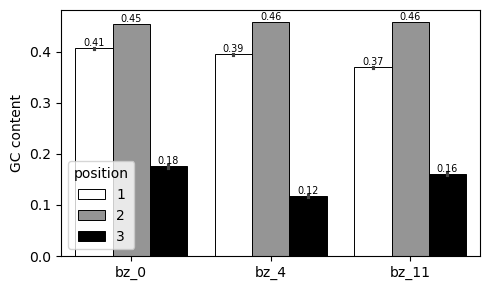

In [27]:
# Are there patterns in the position of GC enrichment? In other words, is GC1, GC2, or GC3 higher? This could indicate the nature of selection pressure on 
# the nucleotide sequencs; there is substantially more flexibility at the third codon position compared to the first or second. 
# If the RNA structure is being selected independently of the protein, there might be a strong effect at third codon positions, because synonymous substitutions 
# there can alter RNA structure without changing the protein.

def get_gc_content_by_position(genes_df:pd.DataFrame):
    ''''''
    df = list()
    for row in genes_df.itertuples():
        codons = [row.nt_seq[i:i + 3] for i in range(0, len(row.nt_seq), 3)]
        gc_counts = np.zeros(3)
        for codon in codons:
            gc_counts += np.isin(list(codon), ['G', 'C']).astype(int)
        df += [{'gene_id':row.Index, 'position':i + 1, 'gc_count':count, 'num_codons':len(codons)} for i, count in enumerate(gc_counts)]
    return pd.DataFrame(df) 


figure_df = list()

for row in genes_df.itertuples():
    codon_usage = get_codon_usage(FASTAFile.from_file(f'../data/genes/prodigal/{row.genome_id}.fna').seqs) # Just use the Prodigal genes to estimate codon usage.

    figure_df_ = get_gc_content_by_position(pd.DataFrame({'nt_seq':get_random_seqs_amino_acids(row.seq, n=500, codon_usage=codon_usage)}))
    figure_df_['genome_id'] = row.genome_id 
    figure_df.append(figure_df_)

figure_df = pd.concat(figure_df)
figure_df['gc_content'] = figure_df.gc_count / figure_df.num_codons

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(figure_df, x='genome_id', y='gc_content', hue='position', palette='Grays', lw=0.7, edgecolor='black')
ax.set_ylabel('GC content')

for containers in ax.containers:
    ax.bar_label(containers, fmt='%.2f', fontsize='x-small')

ax.set_xlabel('')
fig.tight_layout()
plt.show()


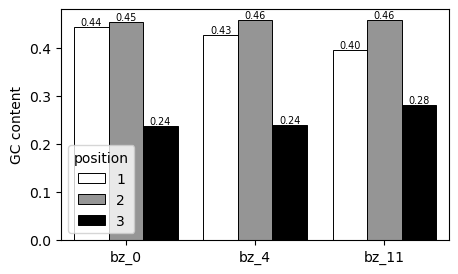

In [28]:
# Are there patterns in the position of GC enrichment? In other words, is GC1, GC2, or GC3 higher? This could indicate the nature of selection pressure on 
# the nucleotide sequencs; there is substantially more flexibility at the third codon position compared to the first or second. 
# If the RNA structure is being selected independently of the protein, there might be a strong effect at third codon positions, because synonymous substitutions 
# there can alter RNA structure without changing the protein.


figure_df = get_gc_content_by_position(genes_df)
figure_df['gc_content'] = figure_df.gc_count / figure_df.num_codons
figure_df['genome_id'] = [get_genome_id(gene_id) for gene_id in figure_df.gene_id]

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(figure_df, x='genome_id', y='gc_content', hue='position', palette='Grays', lw=0.7, edgecolor='black')
ax.set_ylabel('GC content')

for containers in ax.containers:
    ax.bar_label(containers, fmt='%.2f', fontsize='x-small')
    
ax.set_xlabel('')
plt.show()

# The pattern in GC content positions doesn't seem to make a lot of sense, as I would expect GC1 and GC2 to be similar. Probably the best thing to do
# is compute the positional GC content for sequences  with the same amino acid sequence constraints. Maybe this odd pattern is just a result of amino acid-level selction.

In [29]:
n = 500
genome_id = 'bz_0'
gene_id = genes_df[genes_df.genome_id == genome_id].index[0]
nt_seq, seq = genes_df.loc[gene_id].nt_seq, genes_df.loc[gene_id].seq
codon_usage = get_codon_usage(FASTAFile.from_file(f'../data/genes/prodigal/{genome_id}.fna').seqs) # Just use the Prodigal genes to estimate codon usage.

RNAFOLD_DIR = '../data/genes/rnafold/'
RNAFOLD_CONTROL_DIR = os.path.join(RNAFOLD_DIR, 'control', genome_id)
os.makedirs(RNAFOLD_CONTROL_DIR, exist_ok=True) # Make a directory to store the control sequences. 


if os.path.exists(f'analysis-1-cluster_20-rnafold_{genome_id}.csv'):
    rnafold_df = pd.read_csv(f'analysis-1-cluster_20-rnafold_{genome_id}.csv', index_col=0)
else:

    rnafold_df = list()
    rnafold_df += [{'gc_content_control':True, 'codon_usage_control':False, 'amino_acid_control':False, 'nt_seq':nt_seq} for nt_seq in get_random_seqs_gc_content(nt_seq, n=n)]
    rnafold_df += [{'gc_content_control':False, 'codon_usage_control':False, 'amino_acid_control':True, 'nt_seq':nt_seq} for nt_seq in get_random_seqs_amino_acids(seq, n=n)]
    rnafold_df += [{'gc_content_control':False, 'codon_usage_control':True, 'amino_acid_control':True, 'nt_seq':nt_seq} for nt_seq in get_random_seqs_amino_acids(seq, n=n, codon_usage=codon_usage)]
    rnafold_df = pd.DataFrame(rnafold_df).assign(control=True)

    df = list()
    for row in tqdm(list(rnafold_df.itertuples()), desc='Running RNAFold analysis on random RNA sequences.'):
        output_path = os.path.abspath(os.path.join(RNAFOLD_CONTROL_DIR, f'{row.Index}.out'))

        if not os.path.exists(output_path):
            input = f'>{row.Index}\n{row.nt_seq}\n'
            with open(output_path, 'w') as f: # Run RNAFold, suppressing PS output. 
                subprocess.run(['RNAfold', '-p',  '--noPS', '-d2'], input=input, text=True, stdout=f, check=True, cwd=RNAFOLD_CONTROL_DIR)

        df += [RNAFoldOutput(os.path.join(RNAFOLD_CONTROL_DIR, str(row.Index))).get_data()]

    rnafold_df = pd.concat([rnafold_df, pd.DataFrame(df, index=rnafold_df.index)], axis=1) # Add the RNAFold output to the DataFrame.
    rnafold_df.to_csv(f'analysis-1-cluster_20-rnafold_{genome_id}.csv', index=True)

    # shutil.rmtree(RNAFOLD_CONTROL_DIR)
    

for row in tqdm(list(genes_df.itertuples()), desc='Running RNAFold analysis.'):
    name = f'{row.Index}'
    output_path = os.path.abspath(os.path.join(RNAFOLD_DIR, name) + '.out')

    # if os.path.exists(output_path):
    #     continue

    with open(output_path, 'w') as f: 
        subprocess.run(['RNAfold', '-p', '-d2'], input=f'>{name}\n{row.nt_seq}\n', text=True, stdout=f, check=True, cwd=RNAFOLD_DIR)



Running RNAFold analysis.: 100%|██████████| 3/3 [00:01<00:00,  2.04it/s]


In [30]:
genome_ids = ['bz_0', 'bz_4', 'bz_11']

rnafold_df = [pd.read_csv(f'analysis-1-cluster_20-rnafold_{genome_id}.csv', index_col=0).assign(genome_id=genome_id, control=True) for genome_id in genome_ids]
rnafold_df += [pd.DataFrame([RNAFoldOutput(os.path.join(RNAFOLD_DIR, name)).get_data(nt_seq=True) for name in genes_df.index]).assign(control=False).set_index('name')]
rnafold_df = pd.concat(rnafold_df).fillna(False)

rnafold_df['length'] = rnafold_df.nt_seq.apply(len)
rnafold_df['ensemble_free_energy_normalized'] = rnafold_df.ensemble_free_energy / rnafold_df.length
rnafold_df['mfe_free_energy_normalized'] = rnafold_df.mfe_free_energy / rnafold_df.length
rnafold_df['gc_content'] = rnafold_df.nt_seq.apply(get_gc_content)

for gene_id in genes_df.index:
    rnafold_df.loc[gene_id, 'genome_id'] = get_genome_id(gene_id)

Number of bz_0 codon usage-controlled sequences with GC content +/- 0.01: 17
bz_0 p=0.258 (n=500, delta=0.012)
bz_11 p=0.348 (n=500, delta=0.007)
bz_4 p=0.018 (n=500, delta=0.035)


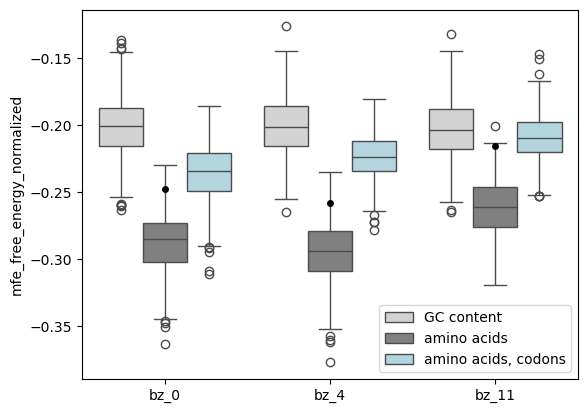

In [31]:

figure_df = rnafold_df[rnafold_df.control].copy() # Get the null distributions.
figure_df['bz_gene_id'] = figure_df.genome_id.map(genes_df.reset_index(names='gene_id').set_index('genome_id').gene_id)
figure_df['bz_gc_content'] = figure_df.bz_gene_id.map(genes_df.gc_content)
figure_df['bz_gc_content_diff'] = np.abs(figure_df.bz_gc_content - figure_df.gc_content)

delta = 0.01
filter_ = (figure_df.codon_usage_control & (figure_df.bz_gc_content_diff < delta))
for genome_id, df in figure_df[filter_].groupby('genome_id'):
    print(f'Number of {genome_id} codon usage-controlled sequences with GC content +/- {delta}:', len(df))


fig, ax = plt.subplots()

metric = 'ensemble_free_energy_normalized'
metric = 'mfe_free_energy_normalized'
# metric = 'ensemble_diversity'
# metric = 'gc_content'

categories = dict()
categories['amino acids'] = figure_df.amino_acid_control & ~figure_df.codon_usage_control
categories['amino acids, codons'] = figure_df.amino_acid_control & figure_df.codon_usage_control
categories['GC content'] = figure_df.gc_content_control.astype(bool) # Sequences explicitly controlling for GC content with no other constraints.

figure_df['category'] = np.select(*list(zip(*categories.items()))[::-1], default='none')

palette = dict()
palette['amino acids'] = 'gray'
palette['amino acids, codons'] = 'lightblue'
palette['amino acids, GC content'] = 'steelblue'
palette['GC content'] = 'lightgray'

sns.boxplot(figure_df, x='genome_id', y=metric, hue='category', palette=palette)
# sns.scatterplot(figure_df[filter_], x='genome_id', y=metric, color='black', s=10)

figure_df = rnafold_df[(~rnafold_df.control)].loc[genes_df.index].copy()
sns.stripplot(figure_df, x='genome_id', y=metric, color='black')

for genome_id, df in figure_df.groupby('genome_id'):
    value = getattr(df.iloc[0], metric)
    # null = rnafold_df[rnafold_df.control & rnafold_df.gc_content_control & (rnafold_df.genome_id == genome_id)][metric].values 
    null = rnafold_df[rnafold_df.control & rnafold_df.codon_usage_control & (rnafold_df.genome_id == genome_id)][metric].values 
    print(f'{genome_id} p={(null < value).mean():.3f} (n={len(null)}, delta={null.mean() - value:.3f})')

ax.set_xlabel('')
plt.show()

# (1) The sequences consistently have higher GC content than the codon frequency-controlled null model. Although this effect is statistically-significant,
#      the magnitude of the difference is fairly small (between 3-5%).
# (2) The sequences generally have slightly lower free energy than the codon usage-controlled null model, though this is only statistically-significant in 
#       bz_11. It is possible that this effect is due to the slightly higher GC content as opposed to any specific secondary structure. 
# (3) In general, the codon usage in the organism results in slightly lower free energy than if GC content was fixed.



In [32]:
# for gene_id in genes_df.index:
#     path = os.path.join(RNAFOLD_DIR, gene_id + '_circular')
#     RNAFoldOutput(path).dotplot()

In [33]:

def get_h_mu(seq, delta:float=100):
    '''Based on the equation from Eisenberg et. al. 1982.
    From https://pmc.ncbi.nlm.nih.gov/articles/PMC3189734/, a typical average hydrophobicity for a TMH is > 0.4 on the non-normalized scale. 
    
    :param delta: The angular rotation between residues, which is 100 degrees for an alpha helix.
    '''
    scale = {'A':0.25, 'R':-1.76, 'N':-0.64, 'D':-0.72, 'C':0.04, 'Q':-0.69, 'E':-0.62, 'G':0.16, 'H':-0.40, 'I':0.73, 'L':0.53, 'K':-1.10, 'M':0.26, 'F':0.61, 'P':-0.07, 'S':-0.26, 'T':-0.18, 'W':0.37, 'Y':0.02, 'V':0.54}
    scale = {'A':0.31,'R':-1.01,'N':-0.60,'D':-0.77,'C':1.54,'Q':-0.22,'E':-0.64,'G':0.00,'H':0.13,'I':1.80,'L':1.70,'K':-0.99,'M':1.23,'F':1.79,'P':0.72,'S':-0.04,'T':0.26,'W':2.25,'Y':0.96,'V':1.22}

    N = len(seq)
    h = sum(scale[aa] for aa in seq) / N # Get the average hydrophobicity.

    # This is the magnitude of the sum of the hydrophobicity vectors for the helix. 
    mu = sum(scale[aa] * np.sin(delta * i) for i, aa in enumerate(seq)) ** 2 
    mu += sum(scale[aa] * np.cos(delta * i) for i, aa in enumerate(seq)) ** 2 
    mu = np.sqrt(mu)
    return h, mu / N

orfm.bz_0.1_114 (70 aa)
orfm.bz_4.1_121 (70 aa)
orfm.bz_11.1_116 (70 aa)


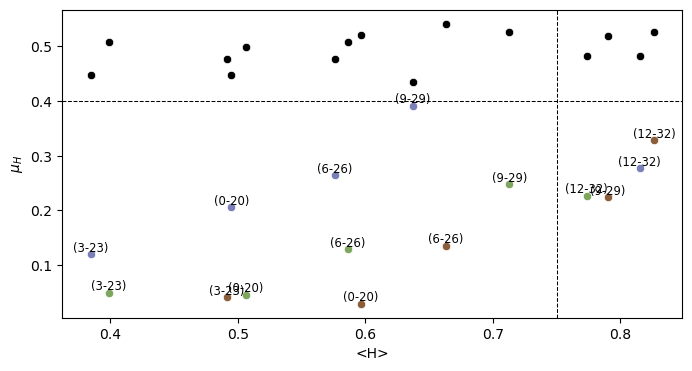

In [34]:
def get_max_mu(seq:str, n:int=200):
    ''''''
    def get_random_seqs(seq:str, n:int=n):
        seq = list(seq)
        seqs = list()
        for _ in range(n):
            np.random.shuffle(seq)
            seqs.append(''.join(seq))
        return seqs

    return max([get_h_mu(s) for s in get_random_seqs(seq)], key=lambda x : x[-1])


def plot_eisenberg(seq, start:int=None, stop:int=None, ax=None, color='gray', plot_max_mu:bool=True, annotate:bool=False, **kwargs):
    ''''''
    seq = seq[start:stop] if ((start is not None) and (stop is not None)) else seq
    h, mu = get_h_mu(seq)

    if annotate:
        ax.text(h, mu, f'({start}-{stop})', ha='center', va='bottom', fontsize='small')

    sns.scatterplot(x=[h], y=[mu], color=color, **kwargs)

    if plot_max_mu:
        h, mu = get_max_mu(seq)
        sns.scatterplot(x=[h], y=[mu], color='black', **kwargs)




def plot(seq, window_size:int=10, step_size:int=3, max_position:int=25, color:str='gray', ax=None):

    starts = np.arange(0, max_position - window_size, step_size)
    stops = [start + window_size for start in starts]
    for start, stop in zip(starts, stops):
        plot_eisenberg(seq, start=start, stop=stop, ax=ax, color=color, annotate=True)



fig, ax = plt.subplots(figsize=(8, 4))
# plot(p69539_seq_processed, window_size=20, max_position=25, color='lightgray', ax=ax)
for row in genes_df.itertuples():
    print(f'{row.Index} ({len(row.seq_processed)} aa)')
    plot(row.seq_processed, window_size=20, max_position=35, color=GENOME_ID_COLORS[get_genome_id(row.Index)], ax=ax)

ax.axhline(0.4, ls='--', color='black', lw=0.75)
ax.axvline(0.75, ls='--', color='black', lw=0.75)
ax.set_xlabel('<H>')
ax.set_ylabel(r'$\mu_H$')

plt.show()

In [ ]:
# mutate = lambda i, old_aa, new_aa, seq : seq[:i] + new_aa + seq[i + 1:] if (seq[i] == old_aa) else seq
# mutated = lambda i, old_aa, new_aa, seq : seq[i] == new_aa

# def mutate_seq(seq:str, mutations:list=list()):
#     ''''''
#     for i, old_aa, new_aa in mutations:
#         seq = mutate(i, old_aa, new_aa, seq)
#         if not mutated(i, old_aa, new_aa, seq):
#             print(f'mutate_seq: Mutation {old_aa}{i}{new_aa} not applied. Residue at {i} is {seq[i]}.')
#     return seq


# def mutate_msa(msa:str, mutations:list=list()):
#     ''''''
#     seqs = list()
#     file = FASTAFile.from_text(msa)

#     for seq in file.seqs:
#         seqs += [mutate_seq(seq, mutations=mutations)]

#     file.seqs = seqs # Update the sequences.

#     return str(file)

# gene_id = 'orfm.bz_0.1_114'
# genome_id = get_genome_id(gene_id)
# seq = genes_df.loc[gene_id].seq
# seq_processed = genes_df.loc[gene_id].seq_processed

# mutations = dict()
# mutations['G33A'] = [(32, 'G', 'A')]
# mutations['T32A_G33A'] = [(31, 'T', 'A'), (32, 'G', 'A')]
# mutations['T32A'] = [(31, 'T', 'A')]

# for code, mutations_ in mutations.items():
#     name = f'{genome_id}_cluster_20_1mer_{code}'
#     input = AlphaFoldInputFile(name=name, dialect='alphafoldserver', num_seeds=1)
#     input.add_seq(mutate_seq(seq_processed, mutations=mutations_), paired_msa='', unpaired_msa=mutate_msa(msas[gene_id], mutations=mutations_))
#     input.write(f'/home/prichter/Downloads/{name}.json')

In [120]:
# # AlphaFold persistently predicts the structure to be a 2-3 helices with a kink partway through.
# # I want to see if I can get it to fold into a filament-like structure if this kink is gone. 

# p69539_seq = 'MKKSLVLKASVAVATLVPMLSFAAEGDDPAKAAFDSLQASATEYIGYAWAMVVVIVGATIGIKLFKKFTSKAS' # Enterobacteria phage fd (Bacteriophage fd) capsid protein Gp8. 
# p69539_seq_processed = 'AAEGDDPAKAAFDSLQASATEYIGYAWAMVVVIVGATIGIKLFKKFTSKAS' # Enterobacteria phage fd (Bacteriophage fd) capsid protein Gp8, with the N-terminal signal peptide removed (see https://www.rcsb.org/sequence/8CH5)
# p69539_signal_peptide_length = len(p69539_seq) - len(p69539_seq_processed)

# # 1 1 Y 1 A ALA 1 ? A ALA 1 
# # 2 1 Y 1 A GLU 2 ? A GLU 2 
# # 3 1 Y 1 A GLY 3 ? A GLY 3 
# # 4 1 Y 1 A ASP 4 ? A ASP 4 
# # 5 1 Y 1 A ASP 5 ? A ASP 5 

# # Corresponding regions in the query and template, respectively. 
# mappings = [(, 'AKAAFDSLQASAT')]
# mappings += [('IIIEAALIVTIVGAILD', 'YIGYAWAMVVVIVGATI')] # The P69539 TMH region is from UniProt (residues 44-62)
# mappings += [('RGKSSWLRSKFER', 'GIKLFKKFTSKAS')]

# mappings = [['DFVGICNTVIGIA']]
# seqs = dict()
# seqs['query'] = seq_processed
# seqs['template'] = p69539_seq_processed

# mappings = dict()
# mappings['query'] = [basic_regions[0], tmh_regions[0], n_terminal_regions[0]]
# mappings['template'] = [basic_regions[1], tmh_regions[1], n_terminal_regions[1]]

# templates = dict()
# templates['mmcif'] = open('../data/genes/alphafold/templates/8ch5.cif', 'r').read()
# templates['queryIndices'] = list()
# templates['templateIndices'] = list()

# for label, mapping in mappings.items():
#     idxs = [re.search(region, seqs[label]) for region in mapping]
#     idxs = np.concat([np.arange(match_.start(), match_.end() - 1) for match_ in idxs]).tolist()
#     templates['queryIndices' if (label == 'query') else 'templateIndices'] = sorted(idxs)

# input = AlphaFoldInputFile(name='bz_0_cluster_20_1mer_processed_with_template', dialect='alphafoldserver', num_seeds=1)
# input.add_seq(seq_processed, paired_msa='', unpaired_msa=msas[gene_id], templates=[templates])
# input.write('/home/prichter/Downloads/test.json')
# # 

# labels = ['cluster_20', 'P69539']
# palette = {'cluster_20':'gray', 'P69539':'lightgray'}
# window_size = 4 // 2
# get_hydrophobicity = lambda seq : np.mean([HYDROPHOBICITY_SCALE[aa] for aa in seq if (aa != msa.gap_symbol)])

# fig, ax = plt.subplots(figsize=(10, 4))

# for seq, label in zip([seq_processed, p69539_seq_processed], labels):
#     windows = [seq[i - window_size:i + window_size] for i in range(window_size, len(seq) - window_size)]
#     values = [get_hydrophobicity(window) for window in windows]
#     ax.plot(np.arange(len(seq) - 2 * window_size), values, color=palette[label], label=label)

# # orfm.bz_0.1_114 TMH from 38-55
# ax.axvline(37, color=palette['cluster_20'], ls='--', lw=0.7)
# ax.axvline(56, color=palette['cluster_20'], ls='--', lw=0.7)

# ax.axvline(44 - p69539_signal_peptide_length, color=palette['P69539'], ls='--', lw=0.7)
# ax.axvline(63 - p69539_signal_peptide_length, color=palette['P69539'], ls='--', lw=0.7)

# ax.set_xticks(np.arange(len(seq_processed)), labels=list(seq_processed))
# # print(cluster_20_seq_processed[56:], f'({len(cluster_20_seq_processed[56:])} aa)')
# # print(cluster_20_seq_processed[37:56], f'({len(cluster_20_seq_processed[37:56])} aa)')
# # print(cluster_20_seq_processed[:20], f'({len(cluster_20_seq_processed[:20])} aa)')

# ax.legend()
# plt.show()



In [ ]:

# if not os.path.exists('analysis-1-cluster_20-iptms.json'): # These AlphaFold jobs were created using the processed forms of the proteins.
#     iptms = dict()
#     for path in glob.glob('../data/genes/alphafold/af_output/ppi-cluster_20/*'):
#         output = AlphaFoldOutput(path, version=4)
#         iptms[output.name] = output.get_iptms(best_model=True)

#     with open('analysis-1-cluster_20-iptms.json', 'wb') as f:
#         f.write(orjson.dumps(iptms, f))

# else:
#     with open('analysis-1-cluster_20-iptms.json', 'rb') as f:
#         iptms = orjson.loads(f.read())


# figure_df = pd.DataFrame.from_dict(iptms, orient='index', columns=['iptm']).reset_index(names='name')
# figure_df['gene_id_0'] = figure_df.name.str.split('-').str[0]
# figure_df['gene_id_1'] = figure_df.name.str.split('-').str[1]
# figure_df['genome_id'] = figure_df.name.apply(get_genome_id)
# figure_df['cluster_id_0'] = figure_df.gene_id_0.map(json.load(open('../data/genes/clusters.json', 'r')))
# figure_df['cluster_id_1'] = figure_df.gene_id_1.map(json.load(open('../data/genes/clusters.json', 'r')))
# figure_df['contact_id'] = figure_df.apply(get_contact_id, axis=1)
# figure_df['cluster_id'] = [row.cluster_id_0 if (row.cluster_id_0 != 20) else row.cluster_id_1 for row in figure_df.itertuples()]
# figure_df['cluster_id'] = figure_df.cluster_id.astype(str)
# figure_df = figure_df[figure_df.iptm > 0.2].copy().sort_values('iptm', ascending=False)

# fig, ax = plt.subplots(figsize=(4, len(figure_df) * 0.2))

# sns.stripplot(figure_df, y='cluster_id', x='iptm', hue='genome_id', palette=GENOME_ID_COLORS)
# ax.set_ylabel('contact ID')
# ax.set_xlabel('IPTM')
# ax.legend().set_title('')

In [ ]:
# Make an AlphaFold input file for the web server for some exploratory analysis on the processed proteins. These were obtained by:
#   (1) N-terminally extending some of the cluster_20 proteins  (those around 80 amino acids in length) to around 95 amino acids.
#   (2) De-replicating the dataset, as some of the sequences differed only in the N-terminal region. 
#   (3) For those with strong signal peptide predictions (all of those with the N-terminal region), obtain the processed sequence using 
#       SignalP, i.e. the protein with the signal peptide cleaved. 


# seq_col = 'seq_processed'
# num_subunits = 2

# inputs = list()
# for path in msa_paths:
#     with open(path, 'r') as f:
#         msa = f.read()
#         print(f'Number of sequences in {path}:', msa.count('>'))

#         gene_id = os.path.basename(path).replace('.a3m', '')
#         input = AlphaFoldInputFile(name=f'{get_genome_id(gene_id)}_cluster_20_{n}mer_processed', num_seeds=1, dialect='alphafoldserver')
#         input.add_seq(database_df.loc[gene_id, seq_col], unpaired_msa=msa, paired_msa="", n=num_subunits)
#         inputs.append(input)

# inputs = [input.get_info() for input in inputs]
# with open('/home/prichter/Downloads/cluster_20.json', 'w') as f:
#     json.dump(inputs, f)


In [ ]:
# for path in glob.glob('../data/genes/alphafold/server/*'):
#     if 'cluster_20_2mer' in path:
#         print(path)
#         output = AlphaFoldServerOutput(path)
#         contact_probs = output.get_contact_probs(best_model=True)
#         paes = output.get_paes(best_model=True)

# contact_probs = contact_probs[:70, -70:]
# sns.kdeplot(contact_probs.ravel())
# row_idxs, col_idxs = np.where(contact_probs > 0.5)
# contact_probs



In [ ]:
# # Two of the three original cluster_20 proteins have a weak annotation for a prokaryotic lipoprotein attachment site (from InterProScan). 
# # Based on this result, I ran SignalP on each of the original cluster_20 proteins, as well as the ggKbase BLAST hits.

# SIGNALP_FIELDS = ['gene_id', 'prediction', 'other', 'sp_sec_spi', 'lipo_sec_spii', 'tat_tat_spi', 'tatlipo_tat_spii)', 'pilin_sec_spiii', 'cleavage_site_position']
# signalp_df = pd.read_csv('../data/genes/signalp/cluster_20.txt', sep='\t', comment='#', names=SIGNALP_FIELDS)

# if 'prediction' not in ggkbase_df.columns:
#     ggkbase_df = ggkbase_df.merge(signalp_df, on='gene_id', how='left')

# ggkbase_df[['gene_id', 'prediction', 'length', 'sp_sec_spi']]

In [ ]:
# for row in genes_df.itertuples():
#     print(f'>{row.Index}')
#     print(row.seq)

In [ ]:
# # SR-VP_9_9_2021_59_4A_0_85m_scaffold_34976_2 is Betazoid.
# # Dalian_Groundwater_SRR22387926_scaffold_135972_3 is Betazoid.
# # SR-VP_07_25_2022_A1_70cm_scaffold_29863_3 is a Betazoid.

# # Based on the GC content, it seems as though some of the hits might belong to Borgs?

# # I wonder if the short sequences have mispredicted starts?


# GGKBASE_DIR = '../data/genes/ggkbase/'
# gene_ids = ['Dalian_Groundwater_SRR22387926_scaffold_135972_3', 'SR-VP_07_25_2022_A1_70cm_scaffold_29863_3']

# ggkbase_df = pd.concat([FASTAFile.from_file(os.path.join(GGKBASE_DIR, f'{gene_id}.faa')).to_df() for gene_id in genes_df.index])
# ggkbase_df.index = [gene_id.split('|')[0] for gene_id in ggkbase_df.index] # Clean up the ggKbase gene IDs.
# ggkbase_df = ggkbase_df[~ggkbase_df.index.duplicated(keep='first')].copy()

# ggkbase_df['contig_id'] = ['_'.join(gene_id.split('_')[:-1]) for gene_id in ggkbase_df.index]
# ggkbase_df['start'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[1].strip())) - 1 # Convert to zero-indexed for my sanity. 
# ggkbase_df['stop'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[2].strip()))
# ggkbase_df['strand'] = ggkbase_df.description.apply(lambda description : int(description.split('#')[3].strip()))
# ggkbase_df = ggkbase_df.loc[gene_ids].copy()
# ggkbase_df['contig'] = ggkbase_df.contig_id.apply(lambda contig_id : FASTAFile.from_file(os.path.join(GGKBASE_DIR, f'{contig_id}.fasta')).seqs[0])


# for row in ggkbase_df.itertuples():
#     if row.strand == -1:
#         contig_length = len(row.contig)
#         ggkbase_df.loc[row.Index, 'strand'] = 1
#         ggkbase_df.loc[row.Index, 'start'] = contig_length - row.stop
#         ggkbase_df.loc[row.Index, 'stop'] = contig_length - row.start
#         ggkbase_df.loc[row.Index, 'contig'] = reverse_complement(row.contig)

# ggkbase_df['nt_seq'] = ggkbase_df.apply(lambda row : row.contig[row.start:row.stop], axis=1)
# ggkbase_df['start_codon'] =  ggkbase_df.apply(lambda row : row.contig[row.start:row.start + 3], axis=1)
# ggkbase_df['stop_codon'] =  ggkbase_df.apply(lambda row : row.contig[row.stop - 3:row.stop], axis=1)

# translate = lambda nt_seq : str(Seq(nt_seq).translate(to_stop=False))

# for row in ggkbase_df.itertuples():
#     nt_seq = row.contig[:row.start] # Get the sequence before the start codon. 
#     nt_seq = nt_seq[len(nt_seq) % 3:] # Make sure it's a length divisible by three; shift start position so the sequence is in-frame.
#     codons = np.array([nt_seq[i:i+3] for i in range(0, len(nt_seq), 3)])
#     stop_codon_idx = np.where(np.isin(codons, STOP_CODONS))[0].max()
    
#     nt_seq = ''.join(codons[-30:])
#     print(nt_seq)
#     print(translate(nt_seq), translate(row.contig[row.start:row.stop]))



In [ ]:
# GGKBASE_DIR = '../data/genes/ggkbase/'

# query_gene_ids = genes_df.index.tolist()

# paths = [os.path.join('../data/genes', f'{gene_id}.faa') for gene_id in genes_df.index]

# database_df = [genes_df[['seq']].copy()]
# database_df += [FASTAFile.from_file(os.path.join(GGKBASE_DIR, f'{gene_id}.faa')).to_df()[['seq']] for gene_id in genes_df.index]
# database_df = pd.concat(database_df)
# database_df = database_df[database_df.seq.apply(len) < 110].copy() # These all seem to be false positives.
# database_df = database_df.drop_duplicates('seq')
# database_df.index = [gene_id.split('|')[0] for gene_id in database_df.index] # Clean up the ggKbase gene IDs.
# database_df = database_df[database_df.index != 'SR2-18-Sp2_coassembly_scaffold_597830_2'].copy() # Don't really trust this hit. 

# assert np.all(np.isin(query_gene_ids, database_df.index)), 'Some of the query sequences are missing from the database.'
# FASTAFile.from_df(database_df).write('../data/genes/mmseqs/cluster_20_database.faa')

# params = dict()
# # params['min_seq_identity'] = 0.99
# # params['num_iterations'] = 3

# msa_paths = msa_main('../data/genes/mmseqs/cluster_20_database.faa', query_gene_ids=query_gene_ids, database_dir='../data/genes/mmseqs/db/', fmt='a3m', name=f'cluster_20', output_dir='../data/genes/mmseqs', **params)

In [ ]:

# if not os.path.exists('analysis-1-cluster_20-contacts.csv'): # These AlphaFold jobs were created using the processed forms of the proteins.
#     contacts_df = list()
#     for path in tqdm(glob.glob('../data/genes/alphafold/af_output/ppi-cluster_20/*'), desc='Loading contact data.'):
#         output = AlphaFoldOutput(path, version=4)
#         contacts_df.append(get_contacts(output, min_contact_prob=0.1))
#     contacts_df = pd.concat(contacts_df)
#     contacts_df.to_csv('analysis-1-cluster_20-contacts.csv', index=False)
# else:
#     contacts_df = pd.read_csv('analysis-1-cluster_20-contacts.csv')


# def get_contact_id(row):
#     '''Construct a contact_id from a contact_df entry. These IDs are of the form {node_type}:{position}.'''
#     residue_num_0 = int(row.residue_num_0) if hasattr(row, 'residue_num_0') else 0 
#     residue_num_1 = int(row.residue_num_1) if hasattr(row, 'residue_num_1') else 0 
#     contact_id = sorted([f'{int(row.cluster_id_0)}:{residue_num_0}', f'{int(row.cluster_id_1)}:{residue_num_1}'])
#     # contact_id = sorted([f'{row.chain_id_0}:{row.residue_num_0}', f'{row.chain_id_1}:{row.residue_num_1}'])
#     return '-'.join(contact_id)

# # Add the N-terminally truncated sequences to the maps so that this doesn't break. 
# for row in genes_df.itertuples():
#     SEQ_TO_CLUSTER_ID_MAP[row.seq_processed] = 20 
#     SEQ_TO_GENE_ID_MAP[row.seq_processed] = row.Index 

# contacts_df['gene_id_0'] = contacts_df.seq_0.map(genes_df.reset_index(names='gene_id').set_index('seq_processed').gene_id)
# contacts_df['gene_id_1'] = contacts_df.seq_1.map(SEQ_TO_GENE_ID_MAP)
# contacts_df['cluster_id_0'] = contacts_df.seq_0.map(SEQ_TO_CLUSTER_ID_MAP)
# contacts_df['cluster_id_1'] = contacts_df.seq_1.map(SEQ_TO_CLUSTER_ID_MAP) # .astype(int) # seq_1 is always then non-cluster_20 protein.
# contacts_df['contact_id'] = contacts_df.apply(get_contact_id, axis=1)
# contacts_df['genome_id'] = contacts_df.name.apply(get_genome_id)

# figure_df = contacts_df[contacts_df.contact_prob > 0].copy()
# figure_df['num_genomes'] = figure_df.contact_id.map(contacts_df.groupby('contact_id').apply(lambda df : df.dropna().genome_id.nunique()))
# # figure_df = figure_df[figure_df.num_genomes > 1].copy() # Keep interactions present in more than one genome.
# figure_df['cluster_id'] = [row.cluster_id_0 if (row.cluster_id_0 != 20) else row.cluster_id_1 for row in figure_df.itertuples()]
# figure_df['cluster_id'] = figure_df['cluster_id'].astype(int).astype(str)

# figure_df = figure_df.sort_values('contact_prob', ascending=False).drop_duplicates(['name', 'model']) # Only keep the best contact from each set of proteins and model.
# figure_df['num_models'] = figure_df.groupby('cluster_id').transform('size') # There should be no duplicate models at this point!
# figure_df = figure_df[figure_df.num_models > 1].copy()

# filter_ = figure_df.groupby('cluster_id', sort=False).apply(lambda df : np.any(df.contact_prob > 0.3))
# cluster_ids = figure_df.cluster_id.unique()[filter_].tolist() + ['25', '17']
# figure_df = figure_df[figure_df.cluster_id.isin(cluster_ids)].copy()

# fig, ax = plt.subplots(figsize=(4, len(figure_df) * 0.05))

# sns.stripplot(figure_df, y='cluster_id', x='contact_prob', hue='genome_id', palette=GENOME_ID_COLORS)
# ax.set_ylabel('cluster ID')
# ax.set_xlabel('contact probability')
# ax.legend().set_title('')

# num_models = figure_df.groupby('cluster_id', sort=False).size().values
# num_models = [f'$n={n}$' for n in num_models][::-1] # Need to reverse the list to make the axes labels correct.
# ax.twinx().set_yticks(np.arange(len(num_models)), labels=num_models)

# for x in 0.1 * np.arange(1, 10):
#     ax.axvline(x, ls='--', color='black', lw=0.5, zorder=-1)

# plt.show()
# # sns.stripplot(figure_df, y='cluster_id_1', x='contact_prob', hue='pae_less_than_10', palette='Grays')